## 1. Configuración y carga de datos

In [18]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

print("Librerías cargadas correctamente ✓")

Librerías cargadas correctamente ✓


In [19]:
# Rutas
DATA_DIR = Path('../data_processed')
INPUT_FILE = DATA_DIR / 'datos_sima_imputados.csv'
CALENDARIO_FILE = DATA_DIR / 'calendario_estaciones_normalized.csv'
OUTPUT_FILE = DATA_DIR / 'datos_aggregados_dia_estacion_franja_imputado.csv'

print(f"Archivo de entrada: {INPUT_FILE}")
print(f"Existe: {INPUT_FILE.exists()}")
print(f"\nArchivo de calendario: {CALENDARIO_FILE}")
print(f"Existe: {CALENDARIO_FILE.exists()}")
print(f"\nArchivo de salida: {OUTPUT_FILE}")

Archivo de entrada: ..\data_processed\datos_sima_imputados.csv
Existe: True

Archivo de calendario: ..\data_processed\calendario_estaciones_normalized.csv
Existe: True

Archivo de salida: ..\data_processed\datos_aggregados_dia_estacion_franja_imputado.csv


In [20]:
# Cargar datos imputados
df = pd.read_csv(INPUT_FILE, parse_dates=['date'])

print(f"Datos imputados cargados:")
print(f"  Dimensiones: {df.shape}")
print(f"  Columnas: {df.columns.tolist()}")
print(f"  Valores faltantes: {df.isnull().sum().sum()}")
print(f"\nPrimeras filas:")
df.head()

Datos imputados cargados:
  Dimensiones: (656490, 4)
  Columnas: ['date', 'estacion', 'parametro', 'valor']
  Valores faltantes: 0

Primeras filas:


,date,estacion,parametro,valor
0,2023-01-01 00:00:00,CENTRO,CO,1.67
1,2023-01-01 01:00:00,CENTRO,CO,1.70
2,2023-01-01 02:00:00,CENTRO,CO,1.51
3,2023-01-01 03:00:00,CENTRO,CO,1.30
4,2023-01-01 04:00:00,CENTRO,CO,1.28


---

# VISUALIZACIÓN Y VALIDACIÓN DE DATOS IMPUTADOS

Esta sección presenta análisis temporales y comparaciones gráficas para **validar la calidad de la imputación** y generar visualizaciones para la presentación.

## 1.5. Librerías adicionales para visualización

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter, MonthLocator
import matplotlib.dates as mdates

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (15, 8)
plt.rcParams['font.size'] = 11

print("✓ Librerías de visualización cargadas")

✓ Librerías de visualización cargadas


## 1.6. Preparación de datos para visualización

In [22]:
# Agregar columnas temporales útiles
df['hora'] = df['date'].dt.hour
df['dia_semana'] = df['date'].dt.dayofweek  # 0=Lunes, 6=Domingo
df['nombre_dia'] = df['date'].dt.day_name()
df['mes'] = df['date'].dt.month
df['nombre_mes'] = df['date'].dt.month_name()
df['fecha_solo'] = df['date'].dt.date

# Crear temporada (verano/invierno)
df['temporada'] = df['mes'].apply(lambda x: 'Verano' if x in [4,5,6,7,8,9] else 'Invierno')

# Mapeo de días en español
dias_es = {
    'Monday': 'Lunes',
    'Tuesday': 'Martes', 
    'Wednesday': 'Miércoles',
    'Thursday': 'Jueves',
    'Friday': 'Viernes',
    'Saturday': 'Sábado',
    'Sunday': 'Domingo'
}
df['nombre_dia_es'] = df['nombre_dia'].map(dias_es)

print(f"✓ Columnas temporales agregadas")
print(f"\nContaminantes disponibles: {sorted(df['parametro'].unique())}")
print(f"Estaciones disponibles: {sorted(df['estacion'].unique())}")
print(f"Rango de fechas: {df['date'].min()} a {df['date'].max()}")
print(f"Total de registros: {len(df):,}")

✓ Columnas temporales agregadas

Contaminantes disponibles: ['CO', 'NO2', 'O3', 'PM10', 'PM2.5']
Estaciones disponibles: ['CENTRO', 'NORESTE3', 'NOROESTE3', 'NORTE2', 'SUR', 'SUROESTE2']
Rango de fechas: 2023-01-01 00:00:00 a 2025-06-30 23:00:00
Total de registros: 656,490


## 1.7. Series Temporales por Contaminante

Visualización de tendencias temporales de cada contaminante para identificar patrones estacionales.

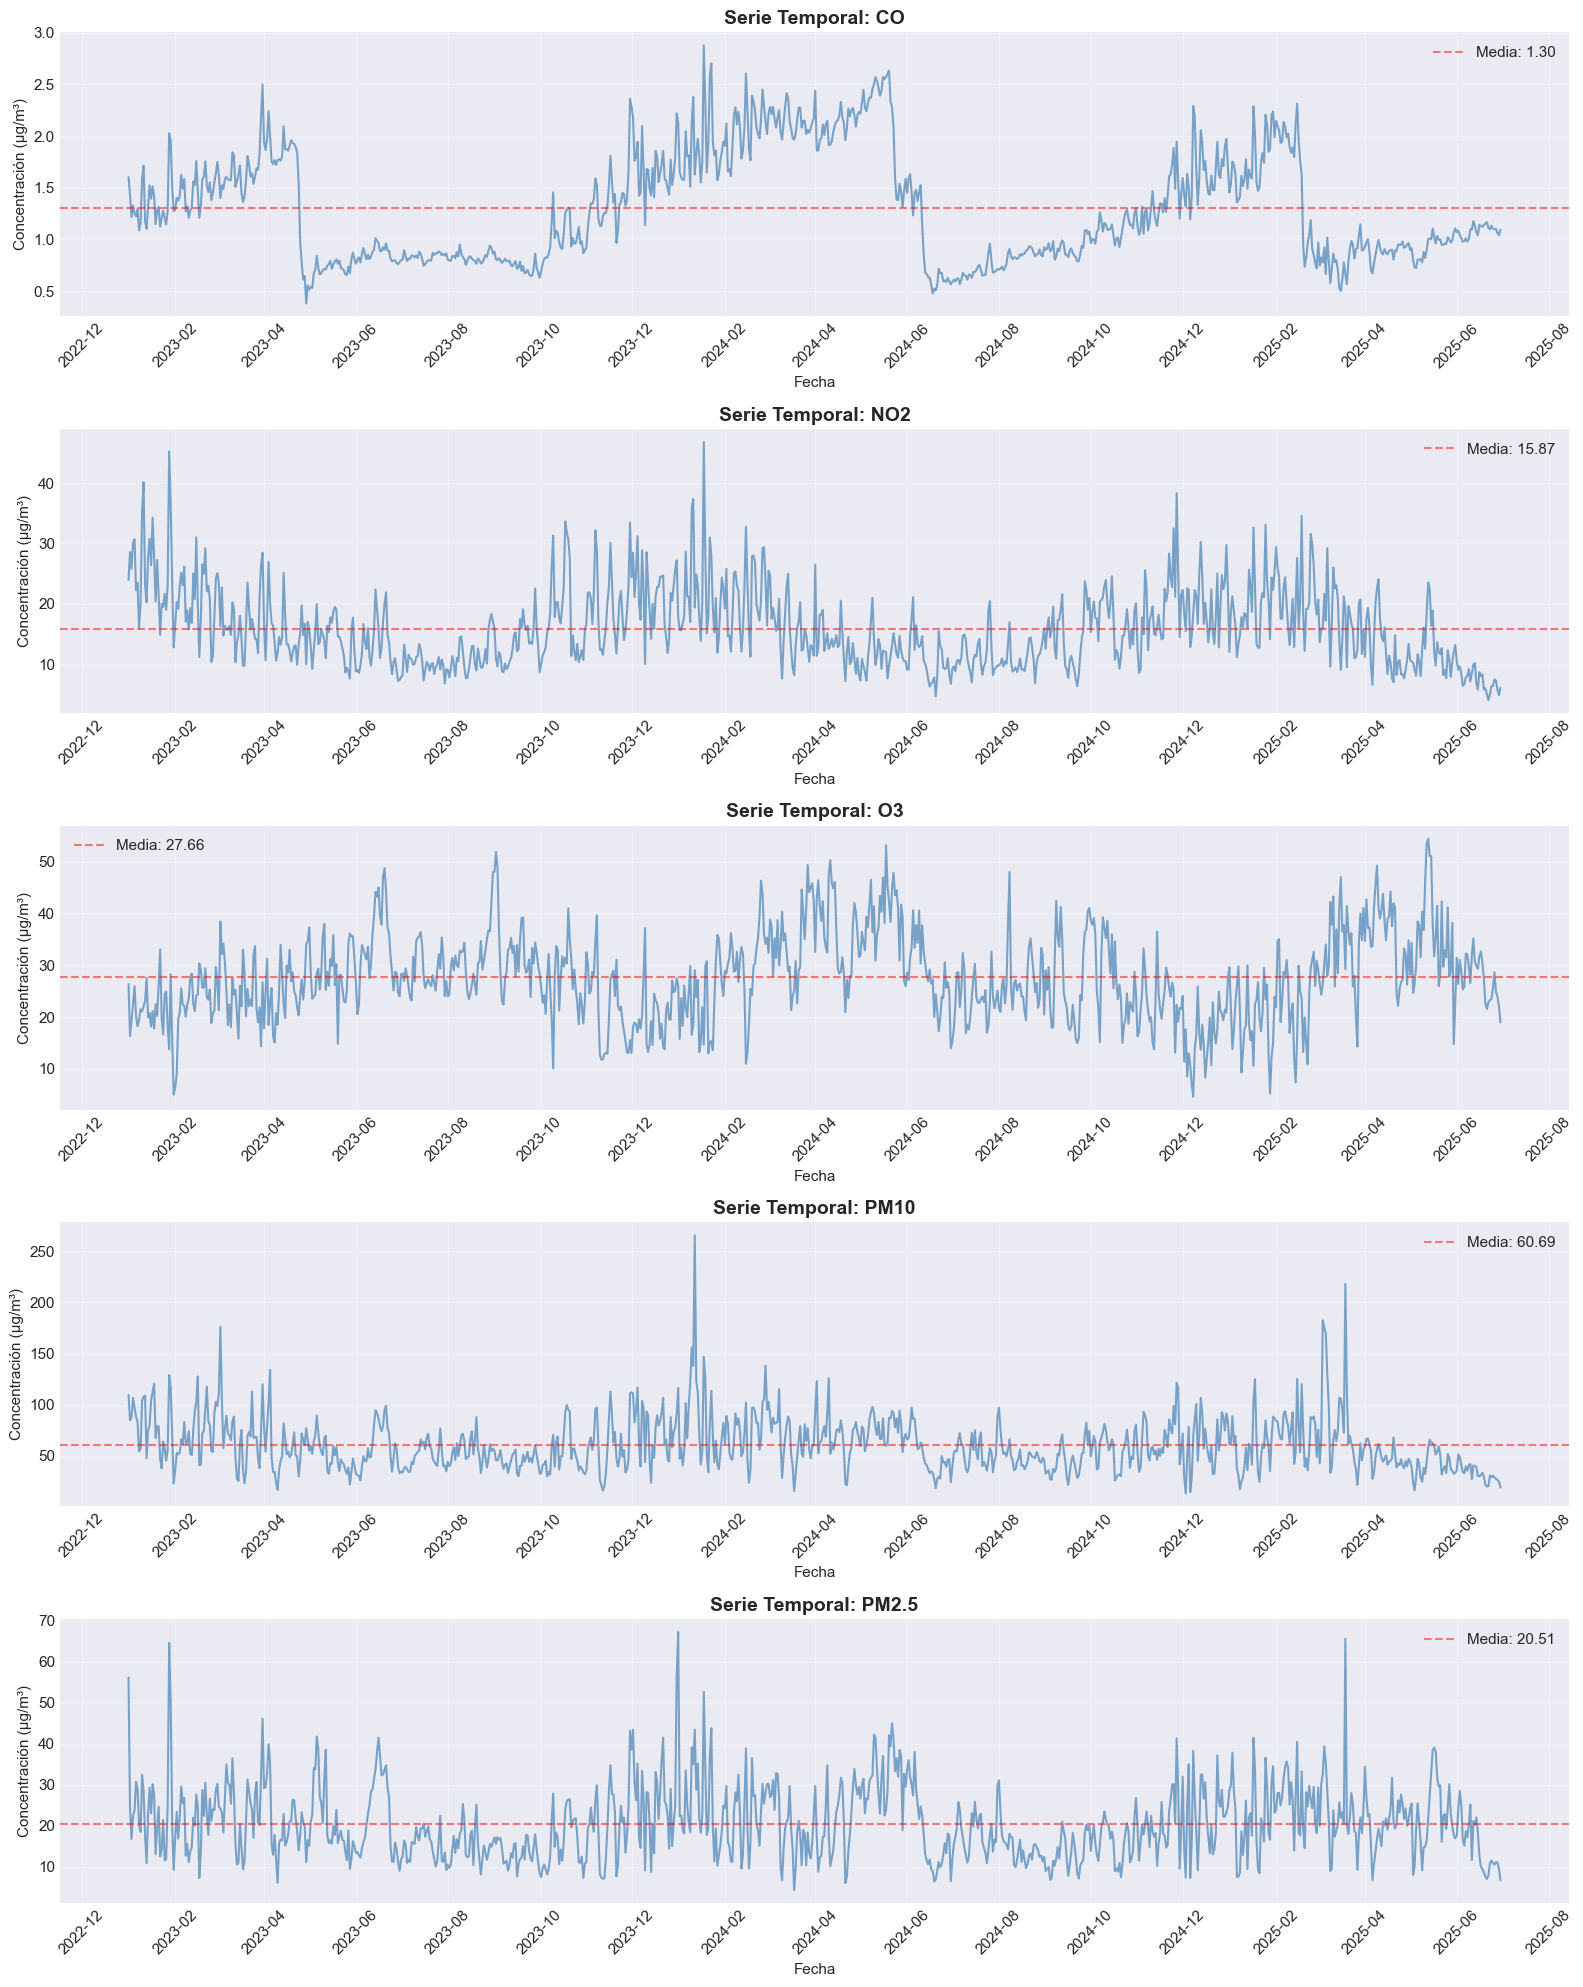

✓ Series temporales generadas para todos los contaminantes


In [23]:
# Calcular promedios diarios por contaminante (todas las estaciones)
df_daily = df.groupby(['fecha_solo', 'parametro'])['valor'].mean().reset_index()
df_daily['fecha_solo'] = pd.to_datetime(df_daily['fecha_solo'])

contaminantes = sorted(df['parametro'].unique())
n_contaminantes = len(contaminantes)

# Crear subplots
fig, axes = plt.subplots(n_contaminantes, 1, figsize=(16, 4*n_contaminantes))
if n_contaminantes == 1:
    axes = [axes]

for idx, contaminante in enumerate(contaminantes):
    data = df_daily[df_daily['parametro'] == contaminante]
    
    axes[idx].plot(data['fecha_solo'], data['valor'], linewidth=1.5, color='steelblue', alpha=0.7)
    axes[idx].set_title(f'Serie Temporal: {contaminante}', fontsize=14, weight='bold')
    axes[idx].set_xlabel('Fecha')
    axes[idx].set_ylabel('Concentración (µg/m³)')
    axes[idx].grid(alpha=0.3)
    
    # Formato de fechas
    axes[idx].xaxis.set_major_formatter(DateFormatter('%Y-%m'))
    axes[idx].xaxis.set_major_locator(MonthLocator(interval=2))
    plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45)
    
    # Estadísticas básicas
    mean_val = data['valor'].mean()
    std_val = data['valor'].std()
    axes[idx].axhline(y=mean_val, color='red', linestyle='--', alpha=0.5, label=f'Media: {mean_val:.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()

print("✓ Series temporales generadas para todos los contaminantes")

## 1.8. Patrones Semanales (Lunes a Domingo)

Comparación de concentraciones por día de la semana para identificar efecto del tráfico escolar.

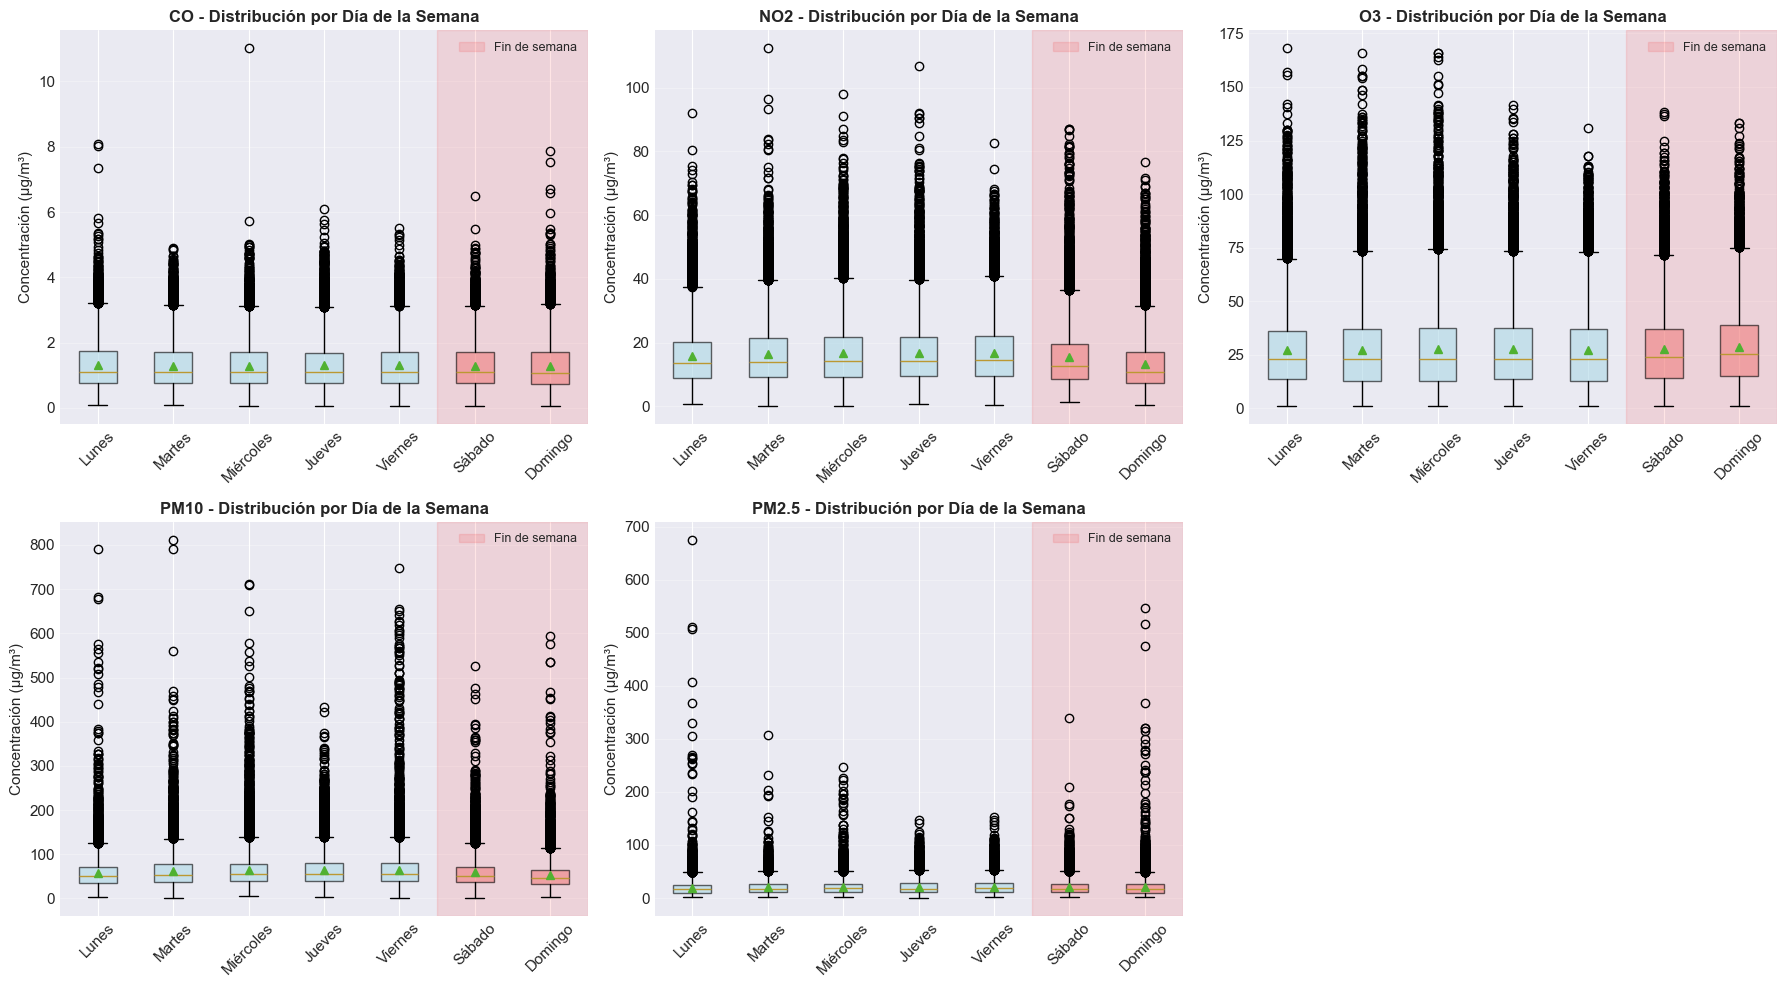

✓ Gráficos de patrones semanales generados


In [24]:
# Calcular promedios por día de la semana y contaminante
df_weekly = df.groupby(['dia_semana', 'nombre_dia_es', 'parametro'])['valor'].mean().reset_index()

# Ordenar días correctamente (Lunes a Domingo)
orden_dias = ['Lunes', 'Martes', 'Miércoles', 'Jueves', 'Viernes', 'Sábado', 'Domingo']
df_weekly['nombre_dia_es'] = pd.Categorical(df_weekly['nombre_dia_es'], categories=orden_dias, ordered=True)
df_weekly = df_weekly.sort_values('nombre_dia_es')

# Crear gráficos
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, contaminante in enumerate(contaminantes):
    if idx < len(axes):
        data = df_weekly[df_weekly['parametro'] == contaminante]
        
        # Box plot con violín
        ax = axes[idx]
        df_cont = df[df['parametro'] == contaminante]
        
        # Ordenar datos para box plot
        df_cont['nombre_dia_es'] = pd.Categorical(df_cont['nombre_dia_es'], categories=orden_dias, ordered=True)
        
        # Crear box plot
        bp = ax.boxplot([df_cont[df_cont['nombre_dia_es'] == dia]['valor'].dropna() 
                          for dia in orden_dias],
                         labels=orden_dias,
                         patch_artist=True,
                         showmeans=True)
        
        # Colorear boxes
        colors = ['lightcoral' if dia in ['Sábado', 'Domingo'] else 'lightblue' for dia in orden_dias]
        for patch, color in zip(bp['boxes'], colors):
            patch.set_facecolor(color)
            patch.set_alpha(0.6)
        
        ax.set_title(f'{contaminante} - Distribución por Día de la Semana', fontsize=12, weight='bold')
        ax.set_ylabel('Concentración (µg/m³)')
        ax.tick_params(axis='x', rotation=45)
        ax.grid(axis='y', alpha=0.3)
        
        # Resaltar fin de semana
        ax.axvspan(5.5, 7.5, alpha=0.1, color='red', label='Fin de semana')
        ax.legend(loc='upper right', fontsize=9)

# Ocultar ejes sobrantes
for idx in range(len(contaminantes), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("✓ Gráficos de patrones semanales generados")

## 1.9. Comparación Entre Semana vs Fin de Semana

Análisis cuantitativo del efecto del tráfico escolar/laboral.

COMPARACIÓN ENTRE SEMANA VS FIN DE SEMANA

CO:
------------------------------------------------------------
  Entre Semana   :     1.30 µg/m³ (σ=  0.72, n=93,732)
  Fin de Semana  :     1.29 µg/m³ (σ=  0.71, n=37,566)
  → Entre semana es 1.0% MAYOR que fin de semana

NO2:
------------------------------------------------------------
  Entre Semana   :    16.50 µg/m³ (σ=  9.95, n=93,732)
  Fin de Semana  :    14.30 µg/m³ (σ=  9.26, n=37,566)
  → Entre semana es 15.4% MAYOR que fin de semana

O3:
------------------------------------------------------------
  Entre Semana   :    27.46 µg/m³ (σ= 19.24, n=93,732)
  Fin de Semana  :    28.16 µg/m³ (σ= 18.04, n=37,566)
  → Entre semana es 2.5% MENOR que fin de semana

PM10:
------------------------------------------------------------
  Entre Semana   :    62.69 µg/m³ (σ= 39.94, n=93,732)
  Fin de Semana  :    55.73 µg/m³ (σ= 33.00, n=37,566)
  → Entre semana es 12.5% MAYOR que fin de semana

PM2.5:
---------------------------------------------

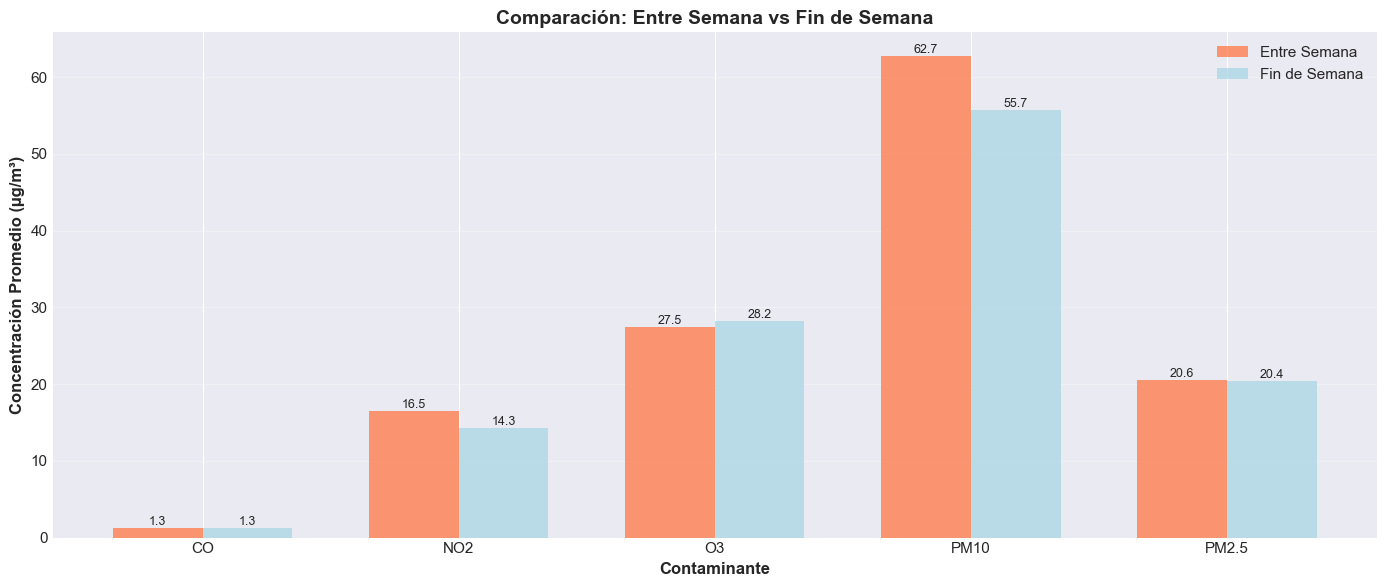

In [25]:
# Clasificar días
df['tipo_dia'] = df['dia_semana'].apply(lambda x: 'Fin de Semana' if x >= 5 else 'Entre Semana')

# Calcular estadísticas
comparison = df.groupby(['parametro', 'tipo_dia'])['valor'].agg(['mean', 'std', 'count']).reset_index()

# Crear tabla comparativa
print("="*80)
print("COMPARACIÓN ENTRE SEMANA VS FIN DE SEMANA")
print("="*80)

for contaminante in contaminantes:
    print(f"\n{contaminante}:")
    print("-"*60)
    
    data_cont = comparison[comparison['parametro'] == contaminante]
    
    for _, row in data_cont.iterrows():
        print(f"  {row['tipo_dia']:15s}: {row['mean']:8.2f} µg/m³ (σ={row['std']:6.2f}, n={int(row['count']):,})")
    
    # Calcular diferencia porcentual
    entre_semana = data_cont[data_cont['tipo_dia'] == 'Entre Semana']['mean'].values[0]
    fin_semana = data_cont[data_cont['tipo_dia'] == 'Fin de Semana']['mean'].values[0]
    diferencia_pct = ((entre_semana - fin_semana) / fin_semana * 100) if fin_semana > 0 else 0
    
    if diferencia_pct > 0:
        print(f"  → Entre semana es {diferencia_pct:.1f}% MAYOR que fin de semana")
    else:
        print(f"  → Entre semana es {abs(diferencia_pct):.1f}% MENOR que fin de semana")

# Gráfico de barras comparativo
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

x = np.arange(len(contaminantes))
width = 0.35

entre_semana_vals = []
fin_semana_vals = []

for contaminante in contaminantes:
    data_cont = comparison[comparison['parametro'] == contaminante]
    entre_semana_vals.append(data_cont[data_cont['tipo_dia'] == 'Entre Semana']['mean'].values[0])
    fin_semana_vals.append(data_cont[data_cont['tipo_dia'] == 'Fin de Semana']['mean'].values[0])

bars1 = ax.bar(x - width/2, entre_semana_vals, width, label='Entre Semana', color='coral', alpha=0.8)
bars2 = ax.bar(x + width/2, fin_semana_vals, width, label='Fin de Semana', color='lightblue', alpha=0.8)

ax.set_xlabel('Contaminante', fontsize=12, weight='bold')
ax.set_ylabel('Concentración Promedio (µg/m³)', fontsize=12, weight='bold')
ax.set_title('Comparación: Entre Semana vs Fin de Semana', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(contaminantes)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Agregar valores sobre las barras
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*80)

## 1.10. Patrones Horarios

Distribución de contaminantes por hora del día.

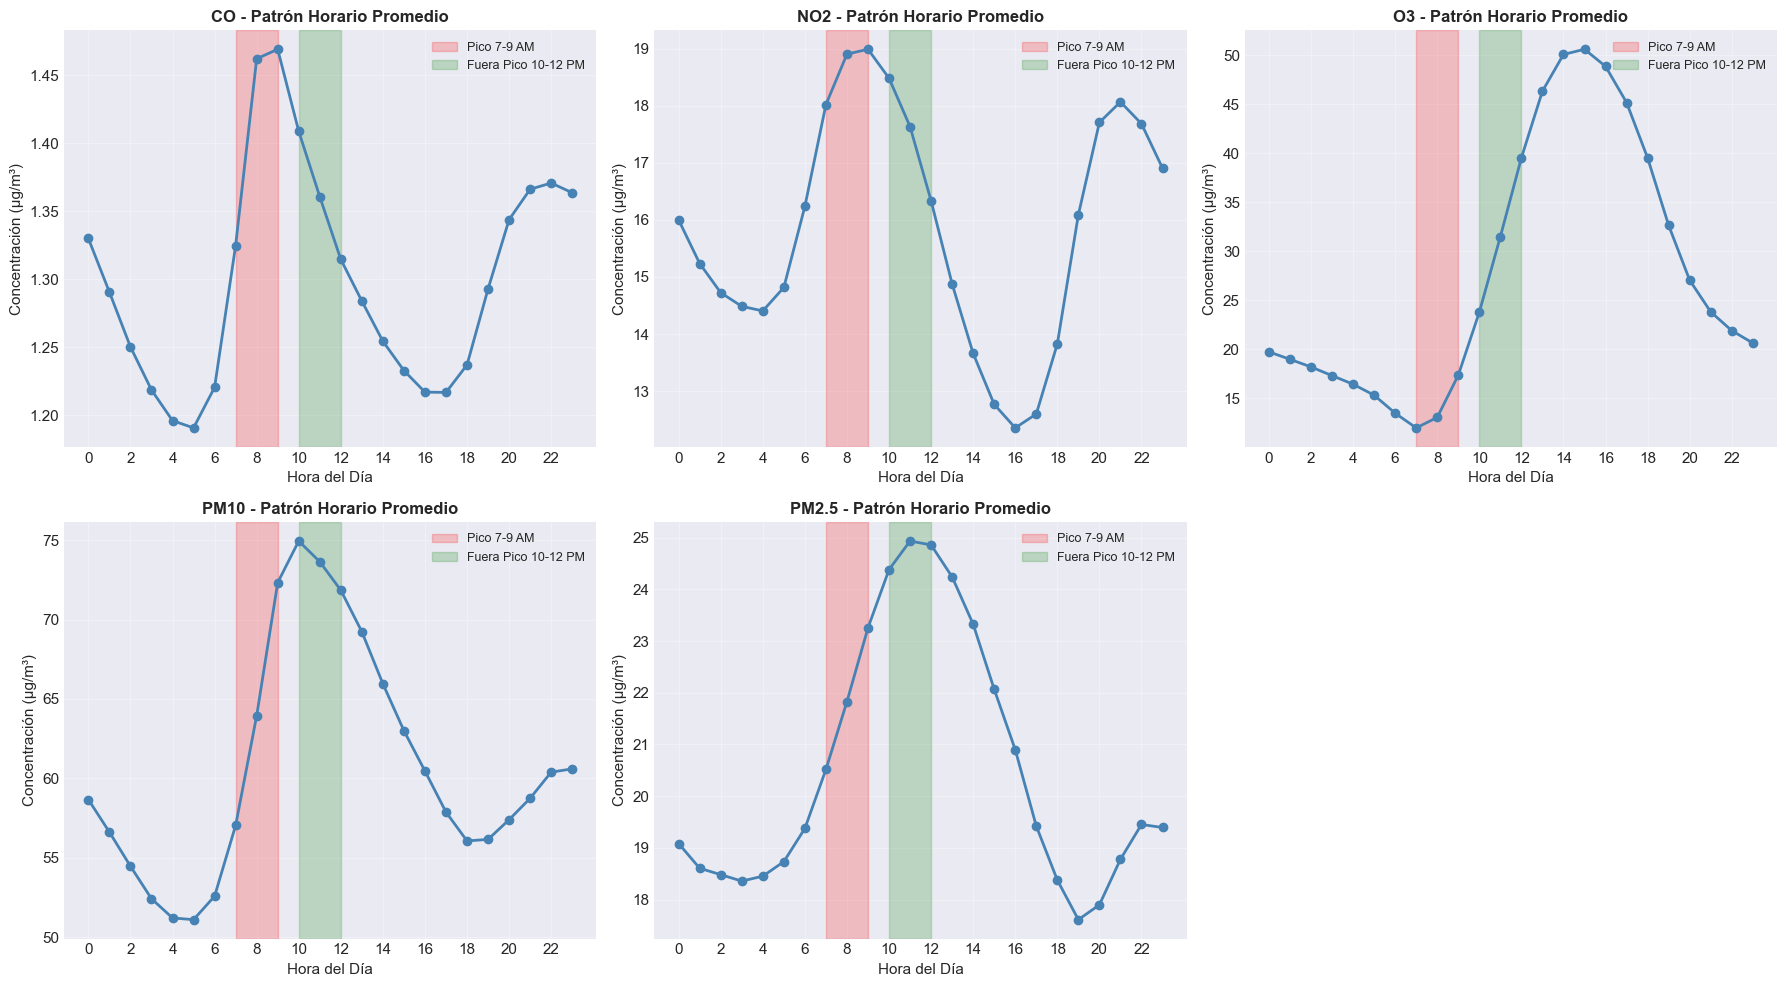

✓ Patrones horarios generados


In [26]:
# Calcular promedios por hora
df_hourly = df.groupby(['hora', 'parametro'])['valor'].mean().reset_index()

# Crear gráficos de líneas por hora
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, contaminante in enumerate(contaminantes):
    if idx < len(axes):
        data = df_hourly[df_hourly['parametro'] == contaminante]
        
        axes[idx].plot(data['hora'], data['valor'], marker='o', linewidth=2, markersize=6, color='steelblue')
        axes[idx].set_title(f'{contaminante} - Patrón Horario Promedio', fontsize=12, weight='bold')
        axes[idx].set_xlabel('Hora del Día')
        axes[idx].set_ylabel('Concentración (µg/m³)')
        axes[idx].set_xticks(range(0, 24, 2))
        axes[idx].grid(alpha=0.3)
        
        # Resaltar franjas de interés
        axes[idx].axvspan(7, 9, alpha=0.2, color='red', label='Pico 7-9 AM')
        axes[idx].axvspan(10, 12, alpha=0.2, color='green', label='Fuera Pico 10-12 PM')
        axes[idx].legend(loc='upper right', fontsize=9)

# Ocultar ejes sobrantes
for idx in range(len(contaminantes), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("✓ Patrones horarios generados")

## 1.11. Comparación Estacional (Verano vs Invierno)

Análisis de diferencias entre temporadas climáticas.

COMPARACIÓN ESTACIONAL: VERANO vs INVIERNO

CO:
------------------------------------------------------------
  Invierno  :     1.53 µg/m³ (σ=  0.69, n=65,502)
  Verano    :     1.08 µg/m³ (σ=  0.67, n=65,796)
  → Invierno es 41.9% MAYOR que verano

NO2:
------------------------------------------------------------
  Invierno  :    19.62 µg/m³ (σ= 10.74, n=65,502)
  Verano    :    12.13 µg/m³ (σ=  7.00, n=65,796)
  → Invierno es 61.8% MAYOR que verano

O3:
------------------------------------------------------------
  Invierno  :    24.60 µg/m³ (σ= 17.96, n=65,502)
  Verano    :    30.69 µg/m³ (σ= 19.33, n=65,796)
  → Invierno es 19.8% MENOR que verano

PM10:
------------------------------------------------------------
  Invierno  :    69.12 µg/m³ (σ= 45.12, n=65,502)
  Verano    :    52.31 µg/m³ (σ= 27.33, n=65,796)
  → Invierno es 32.1% MAYOR que verano

PM2.5:
------------------------------------------------------------
  Invierno  :    22.08 µg/m³ (σ= 16.85, n=65,502)
  Verano    :  

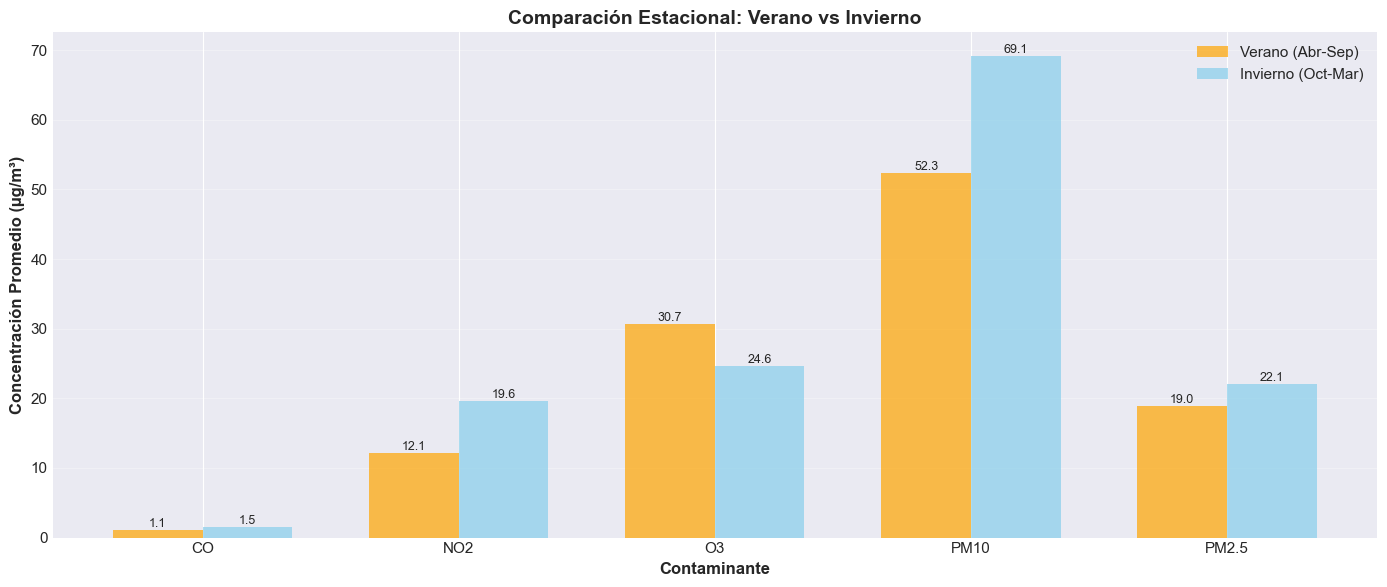

In [27]:
# Calcular estadísticas por temporada
seasonal_comparison = df.groupby(['parametro', 'temporada'])['valor'].agg(['mean', 'std', 'count']).reset_index()

# Tabla comparativa
print("="*80)
print("COMPARACIÓN ESTACIONAL: VERANO vs INVIERNO")
print("="*80)

for contaminante in contaminantes:
    print(f"\n{contaminante}:")
    print("-"*60)
    
    data_cont = seasonal_comparison[seasonal_comparison['parametro'] == contaminante]
    
    for _, row in data_cont.iterrows():
        print(f"  {row['temporada']:10s}: {row['mean']:8.2f} µg/m³ (σ={row['std']:6.2f}, n={int(row['count']):,})")
    
    # Calcular diferencia
    verano = data_cont[data_cont['temporada'] == 'Verano']['mean'].values
    invierno = data_cont[data_cont['temporada'] == 'Invierno']['mean'].values
    
    if len(verano) > 0 and len(invierno) > 0:
        diferencia_pct = ((invierno[0] - verano[0]) / verano[0] * 100) if verano[0] > 0 else 0
        if diferencia_pct > 0:
            print(f"  → Invierno es {diferencia_pct:.1f}% MAYOR que verano")
        else:
            print(f"  → Invierno es {abs(diferencia_pct):.1f}% MENOR que verano")

# Gráfico comparativo
fig, ax = plt.subplots(1, 1, figsize=(14, 6))

x = np.arange(len(contaminantes))
width = 0.35

verano_vals = []
invierno_vals = []

for contaminante in contaminantes:
    data_cont = seasonal_comparison[seasonal_comparison['parametro'] == contaminante]
    
    verano_val = data_cont[data_cont['temporada'] == 'Verano']['mean'].values
    invierno_val = data_cont[data_cont['temporada'] == 'Invierno']['mean'].values
    
    verano_vals.append(verano_val[0] if len(verano_val) > 0 else 0)
    invierno_vals.append(invierno_val[0] if len(invierno_val) > 0 else 0)

bars1 = ax.bar(x - width/2, verano_vals, width, label='Verano (Abr-Sep)', color='orange', alpha=0.7)
bars2 = ax.bar(x + width/2, invierno_vals, width, label='Invierno (Oct-Mar)', color='skyblue', alpha=0.7)

ax.set_xlabel('Contaminante', fontsize=12, weight='bold')
ax.set_ylabel('Concentración Promedio (µg/m³)', fontsize=12, weight='bold')
ax.set_title('Comparación Estacional: Verano vs Invierno', fontsize=14, weight='bold')
ax.set_xticks(x)
ax.set_xticklabels(contaminantes)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

# Agregar valores
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.1f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n" + "="*80)

## 1.12. Heatmap de Correlaciones entre Contaminantes

Matriz de correlación para identificar contaminantes que covarían (ej. tráfico vehicular).

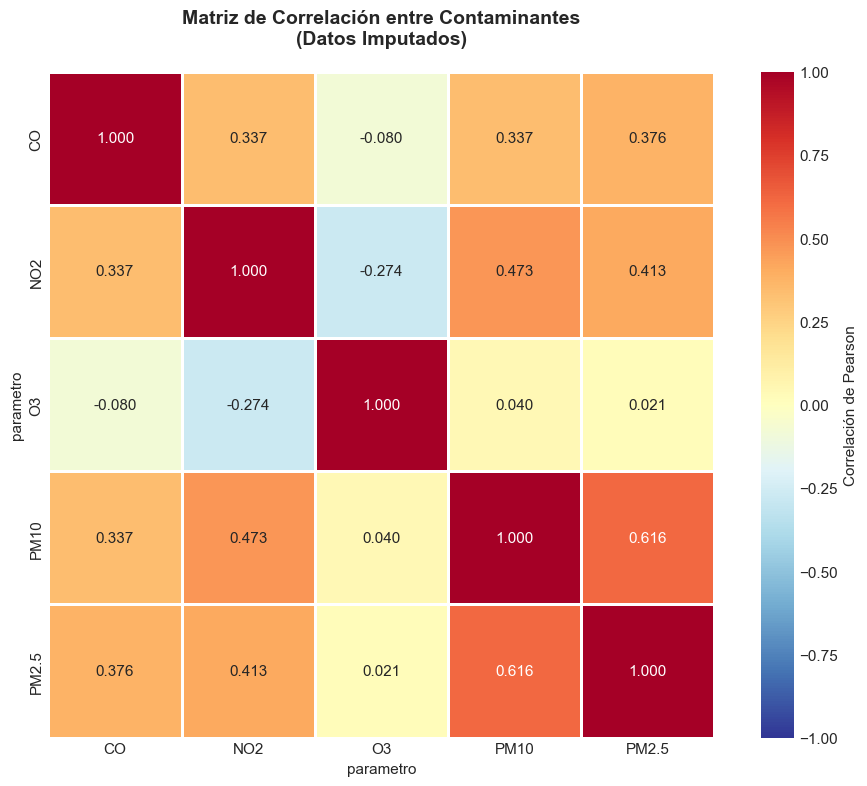

✓ Heatmap de correlaciones generado

Interpretación:
  • Valores cercanos a +1: Fuerte correlación positiva (covarían)
  • Valores cercanos a -1: Fuerte correlación negativa (inversamente proporcionales)
  • Valores cercanos a 0: Sin correlación lineal


In [28]:
# Pivotar datos para tener contaminantes como columnas
df_pivot_corr = df.pivot_table(
    index=['date', 'estacion'],
    columns='parametro',
    values='valor',
    aggfunc='mean'
).reset_index()

# Calcular matriz de correlación
contaminantes_cols = [col for col in df_pivot_corr.columns if col not in ['date', 'estacion']]
corr_matrix = df_pivot_corr[contaminantes_cols].corr()

# Crear heatmap
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

sns.heatmap(corr_matrix, annot=True, fmt='.3f', cmap='RdYlBu_r', center=0,
            square=True, linewidths=1, cbar_kws={'label': 'Correlación de Pearson'},
            vmin=-1, vmax=1, ax=ax)

ax.set_title('Matriz de Correlación entre Contaminantes\n(Datos Imputados)', 
             fontsize=14, weight='bold', pad=20)

plt.tight_layout()
plt.show()

print("✓ Heatmap de correlaciones generado")
print("\nInterpretación:")
print("  • Valores cercanos a +1: Fuerte correlación positiva (covarían)")
print("  • Valores cercanos a -1: Fuerte correlación negativa (inversamente proporcionales)")
print("  • Valores cercanos a 0: Sin correlación lineal")

## 1.13. Comparación por Estación de Monitoreo

Distribución de contaminantes en cada estación SIMA.

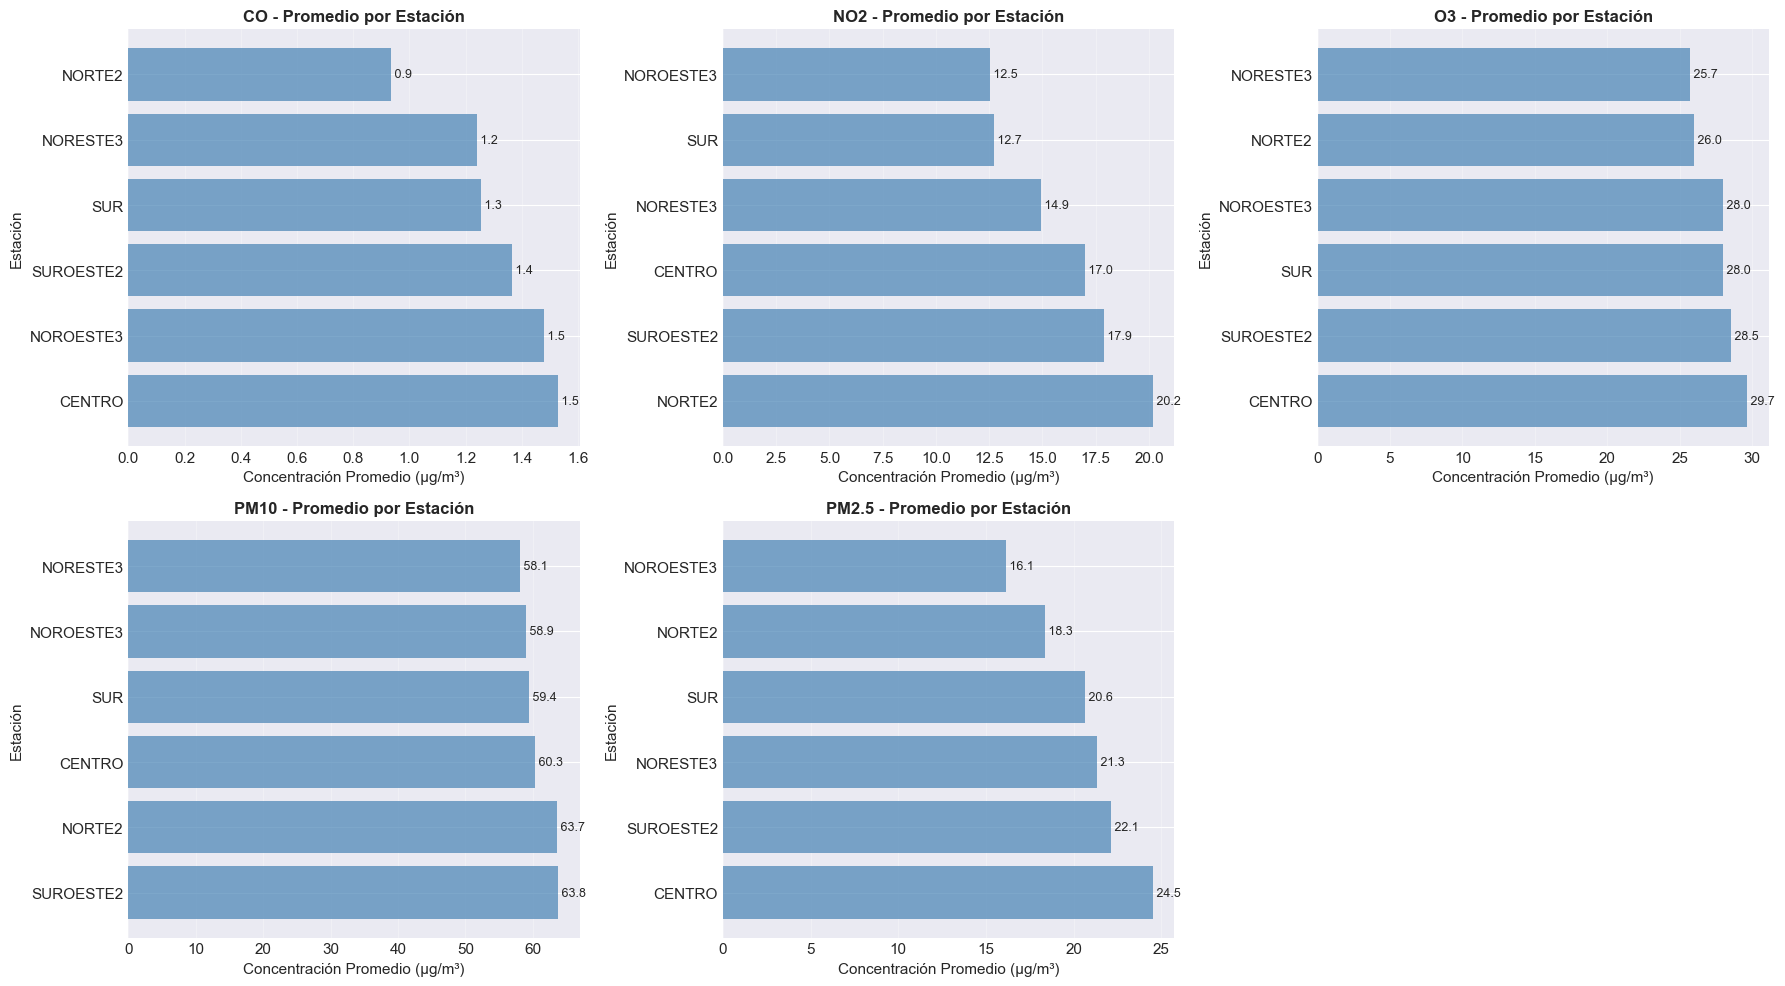

✓ Comparación por estaciones generada


In [29]:
# Calcular promedios por estación y contaminante
df_stations = df.groupby(['estacion', 'parametro'])['valor'].mean().reset_index()

estaciones = sorted(df['estacion'].unique())

# Crear gráficos de barras agrupadas
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, contaminante in enumerate(contaminantes):
    if idx < len(axes):
        data = df_stations[df_stations['parametro'] == contaminante].sort_values('valor', ascending=False)
        
        axes[idx].barh(data['estacion'], data['valor'], color='steelblue', alpha=0.7)
        axes[idx].set_title(f'{contaminante} - Promedio por Estación', fontsize=12, weight='bold')
        axes[idx].set_xlabel('Concentración Promedio (µg/m³)')
        axes[idx].set_ylabel('Estación')
        axes[idx].grid(axis='x', alpha=0.3)
        
        # Agregar valores
        for i, (station, val) in enumerate(zip(data['estacion'], data['valor'])):
            axes[idx].text(val, i, f' {val:.1f}', va='center', fontsize=9)

# Ocultar ejes sobrantes
for idx in range(len(contaminantes), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("✓ Comparación por estaciones generada")

## 1.14. Distribuciones de Densidad

Comparación de distribuciones para identificar normalidad y outliers.

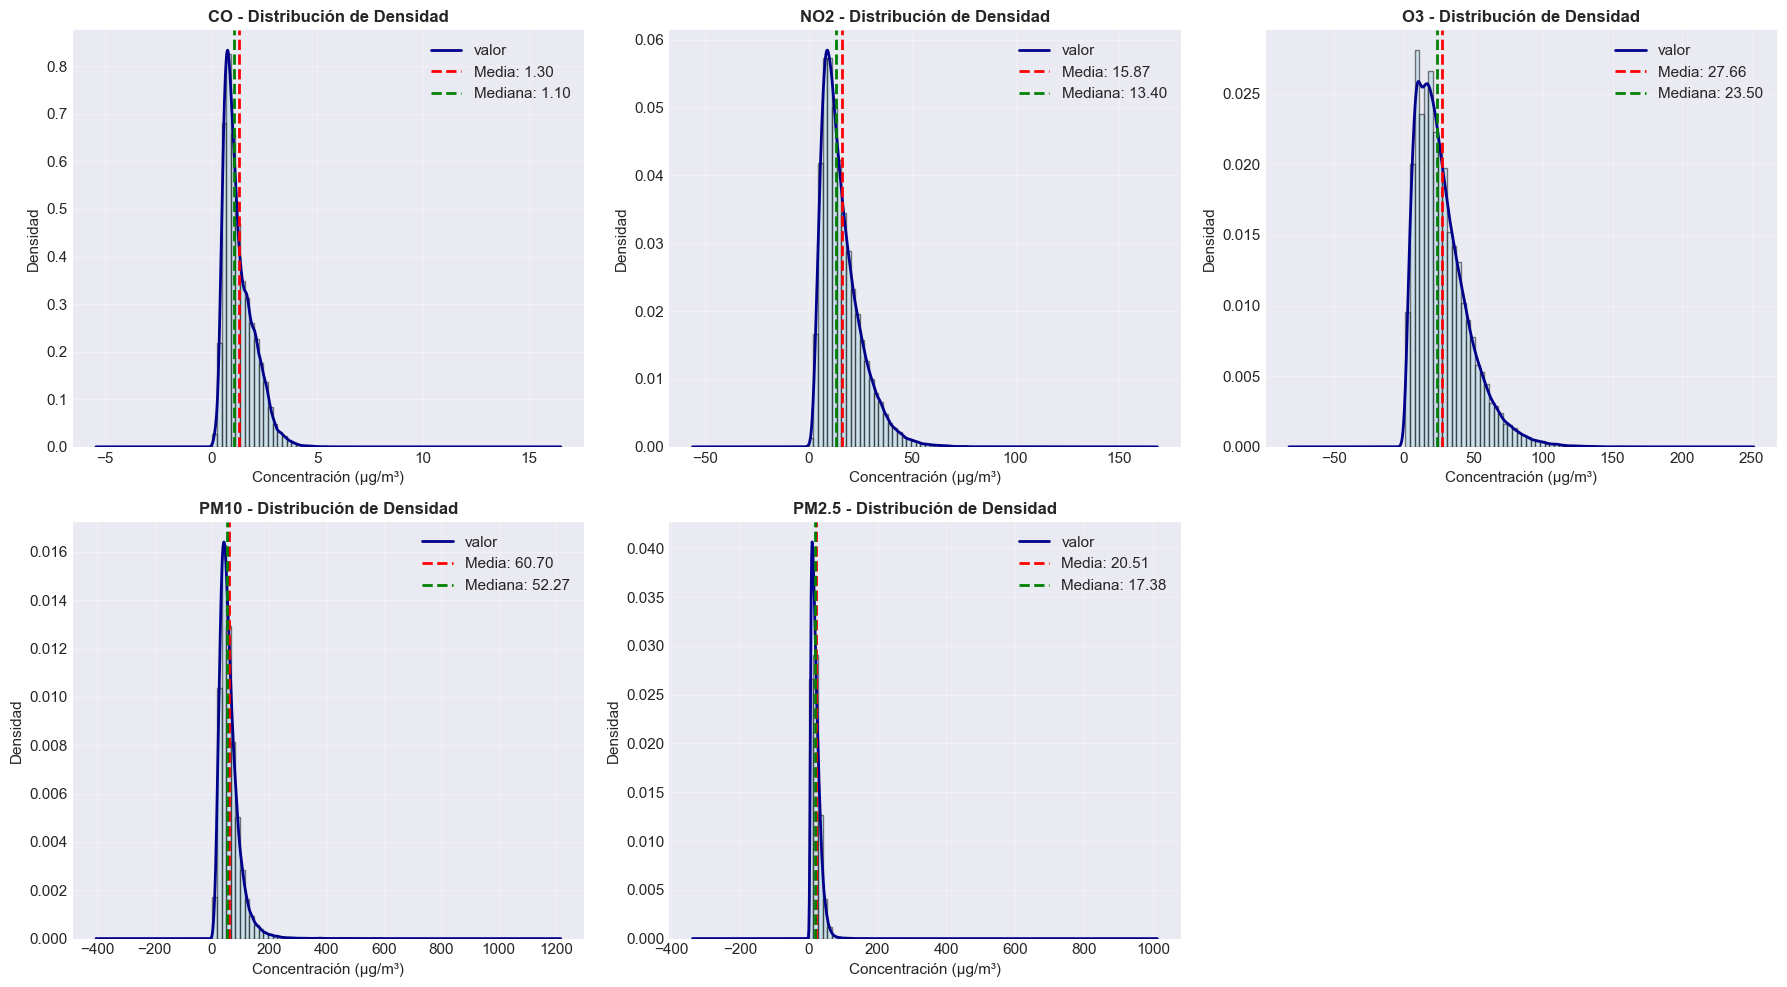

✓ Distribuciones de densidad generadas


In [30]:
# Crear gráficos de densidad (KDE)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, contaminante in enumerate(contaminantes):
    if idx < len(axes):
        data = df[df['parametro'] == contaminante]['valor'].dropna()
        
        # Histograma + KDE
        axes[idx].hist(data, bins=50, density=True, alpha=0.5, color='lightblue', edgecolor='black')
        data.plot.kde(ax=axes[idx], color='darkblue', linewidth=2)
        
        axes[idx].set_title(f'{contaminante} - Distribución de Densidad', fontsize=12, weight='bold')
        axes[idx].set_xlabel('Concentración (µg/m³)')
        axes[idx].set_ylabel('Densidad')
        axes[idx].grid(alpha=0.3)
        
        # Estadísticas
        mean_val = data.mean()
        median_val = data.median()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Media: {mean_val:.2f}')
        axes[idx].axvline(median_val, color='green', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.2f}')
        axes[idx].legend()

# Ocultar ejes sobrantes
for idx in range(len(contaminantes), len(axes)):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("✓ Distribuciones de densidad generadas")

## 1.15. Resumen Estadístico para Presentación

Tabla ejecutiva con estadísticas clave de todos los contaminantes.

RESUMEN ESTADÍSTICO - DATOS IMPUTADOS
parametro  Media  Mediana  Desv_Std  Min    Max   Q25   Q75      N
       CO   1.30     1.10      0.71 0.05  11.02  0.76  1.72 131298
      NO2  15.87    13.40      9.81 0.00 112.35  8.78 20.57 131298
       O3  27.66    23.50     18.90 1.00 168.00 13.50 37.33 131298
     PM10  60.70    52.27     38.22 1.00 811.00 37.00 74.50 131298
    PM2.5  20.51    17.38     14.53 0.00 675.00 10.72 26.92 131298


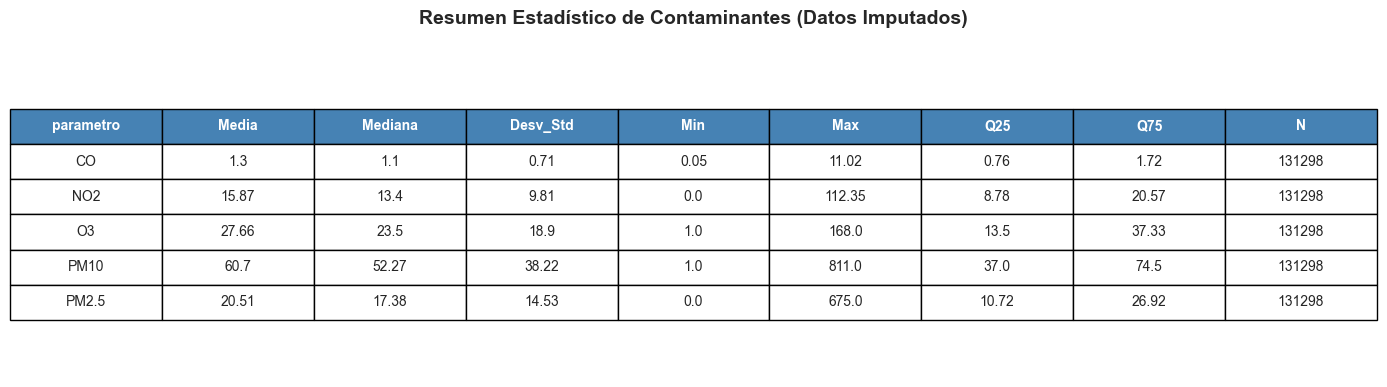


✓ Tabla resumen generada para presentación


In [31]:
# Crear tabla resumen
summary_stats = df.groupby('parametro')['valor'].agg([
    ('Media', 'mean'),
    ('Mediana', 'median'),
    ('Desv_Std', 'std'),
    ('Min', 'min'),
    ('Max', 'max'),
    ('Q25', lambda x: x.quantile(0.25)),
    ('Q75', lambda x: x.quantile(0.75)),
    ('N', 'count')
]).reset_index()

# Redondear valores
for col in ['Media', 'Mediana', 'Desv_Std', 'Min', 'Max', 'Q25', 'Q75']:
    summary_stats[col] = summary_stats[col].round(2)

summary_stats['N'] = summary_stats['N'].astype(int)

print("="*100)
print("RESUMEN ESTADÍSTICO - DATOS IMPUTADOS")
print("="*100)
print(summary_stats.to_string(index=False))
print("="*100)

# Crear visualización de tabla
fig, ax = plt.subplots(1, 1, figsize=(14, 4))
ax.axis('tight')
ax.axis('off')

table_data = summary_stats.values.tolist()
col_labels = summary_stats.columns.tolist()

table = ax.table(cellText=table_data, colLabels=col_labels, cellLoc='center', loc='center',
                colColours=['lightgray']*len(col_labels))
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1, 2)

# Estilizar encabezados
for i in range(len(col_labels)):
    table[(0, i)].set_facecolor('steelblue')
    table[(0, i)].set_text_props(weight='bold', color='white')

plt.title('Resumen Estadístico de Contaminantes (Datos Imputados)', 
          fontsize=14, weight='bold', pad=20)
plt.tight_layout()
plt.show()

print("\n✓ Tabla resumen generada para presentación")

---

## ✅ Resumen de Visualizaciones Generadas

Se han creado las siguientes visualizaciones para validación y presentación:

1. **Series Temporales** - Tendencias de cada contaminante a lo largo del tiempo
2. **Patrones Semanales** - Box plots de Lunes a Domingo
3. **Entre Semana vs Fin de Semana** - Comparación cuantitativa
4. **Patrones Horarios** - Concentraciones por hora del día
5. **Comparación Estacional** - Verano vs Invierno
6. **Matriz de Correlaciones** - Heatmap entre contaminantes
7. **Comparación por Estación** - Gráficos por estación de monitoreo
8. **Distribuciones de Densidad** - Histogramas + KDE
9. **Tabla Resumen Estadístico** - Estadísticas ejecutivas

**Próximo paso**: Continuar con la agregación de datos por día, estación y franja horaria.

---

In [32]:
# Cargar calendario
calendario = pd.read_csv(CALENDARIO_FILE)

print(f"Calendario cargado:")
print(f"  Dimensiones: {calendario.shape}")
print(f"  Columnas: {calendario.columns.tolist()}")

# El calendario tiene formato de rangos (start, end) por estación
# Necesitamos expandirlo a fechas individuales
if 'start' in calendario.columns and 'end' in calendario.columns:
    print("\n✓ Calendario en formato de rangos detectado")
    print("  Expandiendo rangos a fechas individuales...")
    
    # Convertir start y end a datetime
    calendario['start'] = pd.to_datetime(calendario['start'])
    calendario['end'] = pd.to_datetime(calendario['end'])
    
    # Expandir rangos a fechas individuales
    expanded_rows = []
    for _, row in calendario.iterrows():
        date_range = pd.date_range(start=row['start'], end=row['end'], freq='D')
        for date in date_range:
            expanded_rows.append({
                'date': date,
                'estacion': row['estacion'],
                'clase': 1  # Período con clases
            })
    
    calendario_expanded = pd.DataFrame(expanded_rows)
    print(f"  ✓ Calendario expandido: {len(calendario_expanded):,} registros (fecha × estación)")
    
    # Ahora necesitamos crear el complemento: fechas SIN clases
    # Obtenemos rango completo de fechas del dataset
    print("\n  Identificando períodos sin clases (vacaciones)...")
    
else:
    print("\n⚠ Formato de calendario no reconocido")
    calendario_expanded = calendario.copy()

print(f"\nPrimeras filas del calendario expandido:")
calendario_expanded.head(10)

Calendario cargado:
  Dimensiones: (20, 3)
  Columnas: ['estacion', 'start', 'end']

✓ Calendario en formato de rangos detectado
  Expandiendo rangos a fechas individuales...
  ✓ Calendario expandido: 2,741 registros (fecha × estación)

  Identificando períodos sin clases (vacaciones)...

Primeras filas del calendario expandido:


,date,estacion,clase
0,2023-01-09,CENTRO,1
1,2023-01-10,CENTRO,1
2,2023-01-11,CENTRO,1
3,2023-01-12,CENTRO,1
4,2023-01-13,CENTRO,1
5,2023-01-14,CENTRO,1
6,2023-01-15,CENTRO,1
7,2023-01-16,CENTRO,1
8,2023-01-17,CENTRO,1
9,2023-01-18,CENTRO,1


## 2. Agregar hora al dataset

In [33]:
# Extraer hora de la columna date (si tiene timestamp)
if df['date'].dt.hour.max() > 0:
    df['hora'] = df['date'].dt.hour
    print("✓ Columna 'hora' extraída del timestamp")
else:
    print("⚠ El dataset no tiene información de hora. Verifica la estructura.")
    print("  Columnas disponibles:", df.columns.tolist())

# Mostrar distribución de horas
if 'hora' in df.columns:
    print(f"\nDistribución de horas:")
    print(df['hora'].value_counts().sort_index())

✓ Columna 'hora' extraída del timestamp

Distribución de horas:
hora
0     27270
1     27360
2     27360
3     27360
4     27360
5     27360
6     27360
7     27360
8     27360
9     27360
10    27360
11    27360
12    27360
13    27360
14    27360
15    27360
16    27360
17    27330
18    27360
19    27330
20    27360
21    27360
22    27360
23    27360
Name: count, dtype: int64


Distribución de horas:
hora
0     27270
1     27360
2     27360
3     27360
4     27360
5     27360
6     27360
7     27360
8     27360
9     27360
10    27360
11    27360
12    27360
13    27360
14    27360
15    27360
16    27360
17    27330
18    27360
19    27330
20    27360
21    27360
22    27360
23    27360
Name: count, dtype: int64


## 3. Definir franjas horarias

In [34]:
def asignar_franja(hora):
    """
    Asigna franja horaria según la hora.
    - pico_7_9: 7:00 - 8:59 (hora de entrada escolar)
    - fuera_pico_10_12: 10:00 - 11:59 (fuera de pico)
    """
    if 7 <= hora < 9:
        return 'pico_7_9'
    elif 10 <= hora < 12:
        return 'fuera_pico_10_12'
    else:
        return 'otra'

# Asignar franja horaria
if 'hora' in df.columns:
    df['franja_horaria'] = df['hora'].apply(asignar_franja)
    
    print("✓ Franja horaria asignada")
    print(f"\nDistribución de franjas:")
    print(df['franja_horaria'].value_counts())
    
    # Filtrar solo las franjas de interés
    df_filtered = df[df['franja_horaria'].isin(['pico_7_9', 'fuera_pico_10_12'])].copy()
    print(f"\nRegistros después de filtrar franjas: {len(df_filtered):,}")
else:
    print("⚠ No se pudo asignar franja horaria. Verifica que exista la columna 'hora'.")
    df_filtered = df.copy()

✓ Franja horaria asignada

Distribución de franjas:
franja_horaria
otra                547050
pico_7_9             54720
fuera_pico_10_12     54720
Name: count, dtype: int64
franja_horaria
otra                547050
pico_7_9             54720
fuera_pico_10_12     54720
Name: count, dtype: int64

Registros después de filtrar franjas: 109,440

Registros después de filtrar franjas: 109,440


## 4. Agregar datos por día, estación, parámetro y franja

In [35]:
# Crear columna de solo fecha (sin hora)
df_filtered['fecha'] = df_filtered['date'].dt.date

# Agrupar por fecha, estacion, parametro y franja_horaria
df_aggregated = df_filtered.groupby(
    ['fecha', 'estacion', 'parametro', 'franja_horaria']
)['valor'].agg(['mean', 'std', 'min', 'max', 'count']).reset_index()

# Renombrar columnas
df_aggregated.columns = ['date', 'estacion', 'parametro', 'franja_horaria', 
                         'valor_promedio', 'valor_std', 'valor_min', 'valor_max', 'n_mediciones']

# Convertir fecha de nuevo a datetime
df_aggregated['date'] = pd.to_datetime(df_aggregated['date'])

print(f"Datos agregados:")
print(f"  Dimensiones: {df_aggregated.shape}")
print(f"  Registros: {len(df_aggregated):,}")
print(f"\nPrimeras filas:")
df_aggregated.head(10)

Datos agregados:
  Dimensiones: (54720, 9)
  Registros: 54,720

Primeras filas:

  Dimensiones: (54720, 9)
  Registros: 54,720

Primeras filas:


,date,estacion,parametro,franja_horaria,valor_promedio,valor_std,valor_min,valor_max,n_mediciones
0,2023-01-01,CENTRO,CO,fuera_pico_10_12,0.960,0.056569,0.92,1.00,2
1,2023-01-01,CENTRO,CO,pico_7_9,1.010,0.042426,0.98,1.04,2
2,2023-01-01,CENTRO,NO2,fuera_pico_10_12,10.950,2.050610,9.50,12.40,2
3,2023-01-01,CENTRO,NO2,pico_7_9,12.950,0.919239,12.30,13.60,2
4,2023-01-01,CENTRO,O3,fuera_pico_10_12,26.500,2.121320,25.00,28.00,2
5,2023-01-01,CENTRO,O3,pico_7_9,17.500,2.121320,16.00,19.00,2
6,2023-01-01,CENTRO,PM10,fuera_pico_10_12,42.500,2.121320,41.00,44.00,2
7,2023-01-01,CENTRO,PM10,pico_7_9,63.500,28.991378,43.00,84.00,2
8,2023-01-01,CENTRO,PM2.5,fuera_pico_10_12,11.175,2.651650,9.30,13.05,2
9,2023-01-01,CENTRO,PM2.5,pico_7_9,24.115,15.393715,13.23,35.00,2


## 5. Unir con información del calendario

In [36]:
# Preparar calendario completo con períodos CON y SIN clases
print("Creando calendario completo con clases y vacaciones...")

# Obtener rango completo de fechas y estaciones del dataset agregado
fechas_dataset = df_aggregated['date'].unique()
estaciones_dataset = df_aggregated['estacion'].unique()

print(f"  Dataset tiene: {len(fechas_dataset)} fechas únicas y {len(estaciones_dataset)} estaciones")

# Crear calendario completo (todas las combinaciones fecha × estación)
all_combinations = []
for fecha in fechas_dataset:
    for estacion in estaciones_dataset:
        all_combinations.append({'date': fecha, 'estacion': estacion})

calendario_completo = pd.DataFrame(all_combinations)
print(f"  Calendario completo creado: {len(calendario_completo):,} combinaciones")

# Merge con calendario expandido (períodos con clases)
calendario_completo = calendario_completo.merge(
    calendario_expanded[['date', 'estacion', 'clase']],
    on=['date', 'estacion'],
    how='left'
)

# Rellenar NaN con 0 (sin clases / vacaciones)
calendario_completo['clase'] = calendario_completo['clase'].fillna(0).astype(int)

print(f"\nDistribución de clases en calendario completo:")
print(calendario_completo['clase'].value_counts().sort_index())
print(f"  Clase 0 (vacaciones): {(calendario_completo['clase']==0).sum():,}")
print(f"  Clase 1 (con clases): {(calendario_completo['clase']==1).sum():,}")

# Ahora hacer merge con datos agregados
df_final = df_aggregated.merge(
    calendario_completo[['date', 'estacion', 'clase']],
    on=['date', 'estacion'],
    how='left'
)

print(f"\nDespués del merge con calendario:")
print(f"  Dimensiones: {df_final.shape}")
print(f"  Valores faltantes en 'clase': {df_final['clase'].isnull().sum()}")
print(f"\nDistribución de clases en datos finales:")
print(df_final['clase'].value_counts().sort_index())

Creando calendario completo con clases y vacaciones...
  Dataset tiene: 912 fechas únicas y 6 estaciones
  Calendario completo creado: 5,472 combinaciones

Distribución de clases en calendario completo:
clase
0    2747
1    2725
Name: count, dtype: int64
  Clase 0 (vacaciones): 2,747
  Clase 1 (con clases): 2,725

Después del merge con calendario:
  Dimensiones: (54720, 10)
  Valores faltantes en 'clase': 0

Distribución de clases en datos finales:
clase
0    27470
1    27250
Name: count, dtype: int64


## 6. Pivotar para tener un contaminante por columna

In [37]:
# Pivotar para tener formato wide (una columna por contaminante)
df_pivot = df_final.pivot_table(
    index=['date', 'estacion', 'franja_horaria', 'clase'],
    columns='parametro',
    values='valor_promedio'
).reset_index()

# Resetear nombres de columnas
df_pivot.columns.name = None

print(f"Datos en formato wide:")
print(f"  Dimensiones: {df_pivot.shape}")
print(f"  Columnas: {df_pivot.columns.tolist()}")
print(f"\nPrimeras filas:")
df_pivot.head()

Datos en formato wide:
  Dimensiones: (10944, 9)
  Columnas: ['date', 'estacion', 'franja_horaria', 'clase', 'CO', 'NO2', 'O3', 'PM10', 'PM2.5']

Primeras filas:


,date,estacion,franja_horaria,clase,CO,NO2,O3,PM10,PM2.5
0,2023-01-01,CENTRO,fuera_pico_10_12,0,0.960000,10.950000,26.500000,42.500000,11.175
1,2023-01-01,CENTRO,pico_7_9,0,1.010000,12.950000,17.500000,63.500000,24.115
2,2023-01-01,NORESTE3,fuera_pico_10_12,0,1.116667,18.233333,26.666667,84.666667,38.250
3,2023-01-01,NORESTE3,pico_7_9,0,1.604833,25.666667,7.783333,122.666667,79.000
4,2023-01-01,NOROESTE3,fuera_pico_10_12,0,1.171667,10.483333,22.833333,51.333333,16.695


## 7. Verificación de datos

In [38]:
print("="*80)
print("RESUMEN DEL DATASET AGREGADO CON IMPUTACIÓN")
print("="*80)

print(f"\n📊 DIMENSIONES:")
print(f"  • Filas (días × estaciones × franjas): {len(df_pivot):,}")
print(f"  • Columnas: {len(df_pivot.columns)}")

print(f"\n📅 RANGO TEMPORAL:")
print(f"  • Fecha inicial: {df_pivot['date'].min()}")
print(f"  • Fecha final: {df_pivot['date'].max()}")
print(f"  • Días únicos: {df_pivot['date'].nunique():,}")

print(f"\n🏭 ESTACIONES:")
print(f"  • Total: {df_pivot['estacion'].nunique()}")
print(f"  • Nombres: {', '.join(sorted(df_pivot['estacion'].unique()))}")

print(f"\n⏰ FRANJAS HORARIAS:")
for franja in sorted(df_pivot['franja_horaria'].unique()):
    count = (df_pivot['franja_horaria'] == franja).sum()
    pct = count / len(df_pivot) * 100
    print(f"  • {franja}: {count:,} registros ({pct:.1f}%)")

print(f"\n🎓 CLASES (Actividad escolar):")
for clase in sorted(df_pivot['clase'].dropna().unique()):
    count = (df_pivot['clase'] == clase).sum()
    pct = count / len(df_pivot) * 100
    nombre = "Sin clases (vacaciones)" if clase == 0 else "Con clases"
    print(f"  • Clase {int(clase)} - {nombre}: {count:,} registros ({pct:.1f}%)")

print(f"\n🌡️ CONTAMINANTES:")
contaminantes = [col for col in df_pivot.columns if col not in ['date', 'estacion', 'franja_horaria', 'clase']]
for contaminante in contaminantes:
    missing = df_pivot[contaminante].isnull().sum()
    pct_missing = missing / len(df_pivot) * 100
    print(f"  • {contaminante}: {missing:,} faltantes ({pct_missing:.2f}%)")

print(f"\n✅ COMPARACIÓN CON DATASET ORIGINAL (sin imputación):")
print(f"  • Este dataset usa IMPUTACIÓN (interpolación + KNN)")
print(f"  • El dataset original eliminaba filas con dropna()")
print(f"  • Espera: MÁS registros y MENOS valores faltantes que el original")

print("\n" + "="*80)

RESUMEN DEL DATASET AGREGADO CON IMPUTACIÓN

📊 DIMENSIONES:
  • Filas (días × estaciones × franjas): 10,944
  • Columnas: 9

📅 RANGO TEMPORAL:
  • Fecha inicial: 2023-01-01 00:00:00
  • Fecha final: 2025-06-30 00:00:00
  • Días únicos: 912

🏭 ESTACIONES:
  • Total: 6
  • Nombres: CENTRO, NORESTE3, NOROESTE3, NORTE2, SUR, SUROESTE2

⏰ FRANJAS HORARIAS:
  • fuera_pico_10_12: 5,472 registros (50.0%)
  • pico_7_9: 5,472 registros (50.0%)

🎓 CLASES (Actividad escolar):
  • Clase 0 - Sin clases (vacaciones): 5,494 registros (50.2%)
  • Clase 1 - Con clases: 5,450 registros (49.8%)

🌡️ CONTAMINANTES:
  • CO: 0 faltantes (0.00%)
  • NO2: 0 faltantes (0.00%)
  • O3: 0 faltantes (0.00%)
  • PM10: 0 faltantes (0.00%)
  • PM2.5: 0 faltantes (0.00%)

✅ COMPARACIÓN CON DATASET ORIGINAL (sin imputación):
  • Este dataset usa IMPUTACIÓN (interpolación + KNN)
  • El dataset original eliminaba filas con dropna()
  • Espera: MÁS registros y MENOS valores faltantes que el original



## 8. Guardar archivo agregado

In [39]:
# Guardar archivo
print(f"Guardando archivo en: {OUTPUT_FILE}")
df_pivot.to_csv(OUTPUT_FILE, index=False)

print(f"\n✓ Archivo guardado exitosamente!")
print(f"\nResumen del archivo:")
print(f"  • Ruta: {OUTPUT_FILE}")
print(f"  • Dimensiones: {df_pivot.shape}")
print(f"  • Tamaño: {OUTPUT_FILE.stat().st_size / (1024*1024):.2f} MB")
print(f"\n📝 PRÓXIMO PASO:")
print(f"  Ejecutar: 03_analisis_EDA_imputado.ipynb")

Guardando archivo en: ..\data_processed\datos_aggregados_dia_estacion_franja_imputado.csv

✓ Archivo guardado exitosamente!

Resumen del archivo:
  • Ruta: ..\data_processed\datos_aggregados_dia_estacion_franja_imputado.csv
  • Dimensiones: (10944, 9)
  • Tamaño: 0.87 MB

📝 PRÓXIMO PASO:
  Ejecutar: 03_analisis_EDA_imputado.ipynb

✓ Archivo guardado exitosamente!

Resumen del archivo:
  • Ruta: ..\data_processed\datos_aggregados_dia_estacion_franja_imputado.csv
  • Dimensiones: (10944, 9)
  • Tamaño: 0.87 MB

📝 PRÓXIMO PASO:
  Ejecutar: 03_analisis_EDA_imputado.ipynb
